#Importing Libraries

In [178]:
import json
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import pickle
from datetime import datetime
from collections import defaultdict, deque
import time
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2 , f_classif
import seaborn as sns
import matplotlib.pyplot as plt

In [89]:
data=pd.read_csv('/content/dataset_v1 (1).csv')

In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7512 entries, 0 to 7511
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           7512 non-null   object 
 1   flow_id             7234 non-null   float64
 2   in_iface            7234 non-null   object 
 3   event_type          7512 non-null   object 
 4   src_ip              7234 non-null   object 
 5   src_port            7210 non-null   float64
 6   dest_ip             7234 non-null   object 
 7   dest_port           7210 non-null   float64
 8   proto               7234 non-null   object 
 9   app_proto           6042 non-null   object 
 10  flow                7080 non-null   object 
 11  pkt_src             658 non-null    object 
 12  dhcp                12 non-null     object 
 13  alert               504 non-null    object 
 14  direction           504 non-null    object 
 15  icmp_type           224 non-null    float64
 16  icmp_c

In [92]:
data.shape

(7512, 26)

#preprocessing dataset

##Finding Nulls and Removing it

In [93]:
Nulls=dict(data.isna().sum())
sorted_dict = dict(sorted(Nulls.items(), key=lambda item: item[1], reverse=True))

In [95]:
sorted_dict

{'metadata': np.int64(7510),
 'dhcp': np.int64(7500),
 'response_icmp_type': np.int64(7494),
 'response_icmp_code': np.int64(7494),
 'dns': np.int64(7481),
 'fileinfo': np.int64(7479),
 'tx_id': np.int64(7434),
 'http': np.int64(7400),
 'icmp_type': np.int64(7288),
 'icmp_code': np.int64(7288),
 'stats': np.int64(7234),
 'alert': np.int64(7008),
 'direction': np.int64(7008),
 'tcp': np.int64(6925),
 'pkt_src': np.int64(6854),
 'app_proto': np.int64(1470),
 'flow': np.int64(432),
 'src_port': np.int64(302),
 'dest_port': np.int64(302),
 'flow_id': np.int64(278),
 'in_iface': np.int64(278),
 'src_ip': np.int64(278),
 'dest_ip': np.int64(278),
 'proto': np.int64(278),
 'timestamp': np.int64(0),
 'event_type': np.int64(0)}

In [96]:
data.drop(['metadata',
           'dhcp',
           'response_icmp_type',
           'response_icmp_code',
           'dns',
           'fileinfo',
           'tx_id',
           'http',
           'icmp_type',
           'icmp_code',
           'stats',
           'tcp',
           'app_proto',
           'in_iface',
           'flow_id'],axis=1,inplace=True)

In [97]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7512 entries, 0 to 7511
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   timestamp   7512 non-null   object 
 1   event_type  7512 non-null   object 
 2   src_ip      7234 non-null   object 
 3   src_port    7210 non-null   float64
 4   dest_ip     7234 non-null   object 
 5   dest_port   7210 non-null   float64
 6   proto       7234 non-null   object 
 7   flow        7080 non-null   object 
 8   pkt_src     658 non-null    object 
 9   alert       504 non-null    object 
 10  direction   504 non-null    object 
dtypes: float64(2), object(9)
memory usage: 645.7+ KB


In [116]:
Nulls_rows = dict(data.isnull().sum(axis=1))
Nulls_rows_sorted = dict(sorted(Nulls_rows.items(), key=lambda item: item[1], reverse=True))
Nulls_rows_sorted


{0: np.int64(0),
 1: np.int64(0),
 2: np.int64(0),
 3: np.int64(0),
 4: np.int64(0),
 5: np.int64(0),
 6: np.int64(0),
 7: np.int64(0),
 8: np.int64(0),
 9: np.int64(0),
 10: np.int64(0),
 11: np.int64(0),
 12: np.int64(0),
 13: np.int64(0),
 14: np.int64(0),
 15: np.int64(0),
 16: np.int64(0),
 17: np.int64(0),
 18: np.int64(0),
 19: np.int64(0),
 20: np.int64(0),
 21: np.int64(0),
 22: np.int64(0),
 23: np.int64(0),
 24: np.int64(0),
 25: np.int64(0),
 26: np.int64(0),
 27: np.int64(0),
 28: np.int64(0),
 29: np.int64(0),
 30: np.int64(0),
 31: np.int64(0),
 32: np.int64(0),
 33: np.int64(0),
 34: np.int64(0),
 35: np.int64(0),
 36: np.int64(0),
 37: np.int64(0),
 38: np.int64(0),
 39: np.int64(0),
 40: np.int64(0),
 41: np.int64(0),
 42: np.int64(0),
 43: np.int64(0),
 44: np.int64(0),
 45: np.int64(0),
 46: np.int64(0),
 47: np.int64(0),
 48: np.int64(0),
 49: np.int64(0),
 50: np.int64(0),
 51: np.int64(0),
 52: np.int64(0),
 53: np.int64(0),
 54: np.int64(0),
 55: np.int64(0),
 5

In [121]:
data.reset_index(inplace=True)
data.drop("index",axis=1,inplace=True)

In [123]:
data

,timestamp,event_type,src_ip,src_port,dest_ip,dest_port,proto,flow,pkt_src,alert,direction
0,2026-02-04 09:52:20.437770+00:00,alert,192.168.152.171,47418.0,172.16.1.60,22.0,TCP,"{'pkts_toserver': 6, 'pkts_toclient': 5, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server
1,2026-02-04 09:52:24.691136+00:00,alert,172.16.1.60,22.0,192.168.152.171,47418.0,TCP,"{'pkts_toserver': 7, 'pkts_toclient': 7, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_client
2,2026-02-04 09:52:32.881562+00:00,alert,172.16.1.60,22.0,192.168.152.171,47418.0,TCP,"{'pkts_toserver': 8, 'pkts_toclient': 8, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_client
3,2026-02-04 09:53:05.491297+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server
4,2026-02-04 09:53:06.490446+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server
...,...,...,...,...,...,...,...,...,...,...,...
499,2026-02-04 12:16:49.042422+00:00,alert,192.168.152.171,25577.0,172.16.1.60,0.0,UDP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server
500,2026-02-04 12:16:52.545677+00:00,alert,192.168.152.171,21527.0,172.16.1.60,0.0,UDP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server
501,2026-02-04 12:16:54.792306+00:00,alert,192.168.152.171,29978.0,172.16.1.60,0.0,UDP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server
502,2026-02-04 12:16:56.956782+00:00,alert,192.168.152.171,31459.0,172.16.1.60,0.0,UDP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server


In [124]:
data.shape

(504, 11)

In [126]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   timestamp   504 non-null    object 
 1   event_type  504 non-null    object 
 2   src_ip      504 non-null    object 
 3   src_port    504 non-null    float64
 4   dest_ip     504 non-null    object 
 5   dest_port   504 non-null    float64
 6   proto       504 non-null    object 
 7   flow        504 non-null    object 
 8   pkt_src     504 non-null    object 
 9   alert       504 non-null    object 
 10  direction   504 non-null    object 
dtypes: float64(2), object(9)
memory usage: 43.4+ KB


In [127]:
data.shape

(504, 11)

##Feature Extractions


In [128]:
data["alert"].tolist()

["{'action': 'allowed', 'gid': 1, 'signature_id': 2000006, 'rev': 32, 'signature': 'SSH Brute Force Attack Detected', 'category': 'Attempted Administrator Privilege Gain', 'severity': 1}",
 "{'action': 'allowed', 'gid': 1, 'signature_id': 2210055, 'rev': 2, 'signature': 'SURICATA STREAM 3way handshake excessive different SYN/ACKs', 'category': 'Generic Protocol Command Decode', 'severity': 3}",
 "{'action': 'allowed', 'gid': 1, 'signature_id': 2210055, 'rev': 2, 'signature': 'SURICATA STREAM 3way handshake excessive different SYN/ACKs', 'category': 'Generic Protocol Command Decode', 'severity': 3}",
 "{'action': 'allowed', 'gid': 1, 'signature_id': 2100366, 'rev': 8, 'signature': 'GPL ICMP PING *NIX', 'category': 'Misc activity', 'severity': 3, 'metadata': {'confidence': ['Medium'], 'created_at': ['2010_09_23'], 'signature_severity': ['Informational'], 'tag': ['Description_Generated_By_Proofpoint_Nexus'], 'updated_at': ['2019_07_26']}}",
 "{'action': 'allowed', 'gid': 1, 'signature_id'

In [129]:
def extract_signature(alert_str):
    try:
        # Safely evaluate the string as a Python literal (dictionary)
        alert_dict = eval(alert_str)
        return alert_dict.get('signature', 'Unknown')
    except (SyntaxError, ValueError):
        return 'Unknown' # Handle cases where string is not a valid dictionary

data['Attack_Type'] = data['alert'].apply(extract_signature)
display(data.head())

,timestamp,event_type,src_ip,src_port,dest_ip,dest_port,proto,flow,pkt_src,alert,direction,Attack_Type
0,2026-02-04 09:52:20.437770+00:00,alert,192.168.152.171,47418.0,172.16.1.60,22.0,TCP,"{'pkts_toserver': 6, 'pkts_toclient': 5, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,SSH Brute Force Attack Detected
1,2026-02-04 09:52:24.691136+00:00,alert,172.16.1.60,22.0,192.168.152.171,47418.0,TCP,"{'pkts_toserver': 7, 'pkts_toclient': 7, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_client,SURICATA STREAM 3way handshake excessive diffe...
2,2026-02-04 09:52:32.881562+00:00,alert,172.16.1.60,22.0,192.168.152.171,47418.0,TCP,"{'pkts_toserver': 8, 'pkts_toclient': 8, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_client,SURICATA STREAM 3way handshake excessive diffe...
3,2026-02-04 09:53:05.491297+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,GPL ICMP PING *NIX
4,2026-02-04 09:53:06.490446+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,GPL ICMP PING *NIX


In [130]:
attack_types_to_remove = [
    'SURICATA STREAM 3way handshake excessive different SYN/ACKs',
    'SSH Brute Force Attack Detected',
    'ET SCAN Potential SSH Scan',
    'SURICATA STREAM excessive retransmissions'
]

data = data[~data['Attack_Type'].isin(attack_types_to_remove)]
display(data['Attack_Type'].value_counts())

,count
Attack_Type,
GPL ICMP PING *NIX,112
potential ICMP Flood DoS Attack,88
Potential XMAS Scan Detected,84
potential UDP Flood DoS Attack,25
Potential NULL Scan Detected,10
Potential FIN Scan Detected,9


In [131]:
data.shape

(328, 12)

In [133]:
data['Attack_Type'] = data['Attack_Type'].replace({
    'GPL ICMP PING *NIX': 'Normal Traffic',
    'potential ICMP Flood DoS Attack': 'DDos',
    'potential UDP Flood DoS Attack': 'DDos',
    'Potential XMAS Scan Detected': 'Port Scan',
    'Potential NULL Scan Detected': 'Port Scan',
    'Potential FIN Scan Detected': 'Port Scan'
})
display(data['Attack_Type'].value_counts())

/tmp/ipython-input-3594474564.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Attack_Type'] = data['Attack_Type'].replace({


,count
Attack_Type,
DDos,113
Normal Traffic,112
Port Scan,103


In [136]:
data.head()

,timestamp,event_type,src_ip,src_port,dest_ip,dest_port,proto,flow,pkt_src,alert,direction,Attack_Type
3,2026-02-04 09:53:05.491297+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic
4,2026-02-04 09:53:06.490446+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic
5,2026-02-04 09:53:07.498374+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 3, 'pkts_toclient': 2, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic
8,2026-02-04 09:53:45.272827+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic
9,2026-02-04 09:53:46.273364+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic


In [147]:
data.reset_index(inplace=True)
data.head()

,index,timestamp,event_type,src_ip,src_port,dest_ip,dest_port,proto,flow,pkt_src,alert,direction,Attack_Type
0,0,2026-02-04 09:53:05.491297+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic
1,1,2026-02-04 09:53:06.490446+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic
2,2,2026-02-04 09:53:07.498374+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 3, 'pkts_toclient': 2, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic
3,3,2026-02-04 09:53:45.272827+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic
4,4,2026-02-04 09:53:46.273364+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic


In [148]:
data.shape

(328, 13)

In [149]:
def extract_flow_metrics(flow_str):
    try:
        flow_dict = eval(flow_str)
        return (
            flow_dict.get('pkts_toserver', 0),
            flow_dict.get('pkts_toclient', 0),
            flow_dict.get('bytes_toserver', 0),
            flow_dict.get('bytes_toclient', 0)
        )
    except (SyntaxError, ValueError):
        return (0, 0, 0, 0)  # Return default values in case of error

data[['pkts_toserver', 'pkts_toclient', 'bytes_toserver', 'bytes_toclient']] = \
    data['flow'].apply(extract_flow_metrics).tolist()

display(data.head())

/tmp/ipython-input-728797935.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[['pkts_toserver', 'pkts_toclient', 'bytes_toserver', 'bytes_toclient']] = \
/tmp/ipython-input-728797935.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[['pkts_toserver', 'pkts_toclient', 'bytes_toserver', 'bytes_toclient']] = \
/tmp/ipython-input-728797935.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

,index,timestamp,event_type,src_ip,src_port,dest_ip,dest_port,proto,flow,pkt_src,alert,direction,Attack_Type,pkts_toserver,pkts_toclient,bytes_toserver,bytes_toclient
0,0,2026-02-04 09:53:05.491297+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,1,0,98,0
1,1,2026-02-04 09:53:06.490446+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,2,1,196,98
2,2,2026-02-04 09:53:07.498374+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 3, 'pkts_toclient': 2, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,3,2,294,196
3,3,2026-02-04 09:53:45.272827+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,1,0,98,0
4,4,2026-02-04 09:53:46.273364+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,2,1,196,98


In [154]:
import pandas as pd
import ast

def get_flow_duration(row):
    # Parse the 'flow' dictionary string
    if pd.isna(row['flow']):
        return 0.0

    flow_dict = ast.literal_eval(row['flow'])

    # 1. Check if 'age' is already provided (usually in 'flow' event records)
    if 'age' in flow_dict:
        return float(flow_dict['age'])

    # 2. Calculate duration if 'age' is missing (for 'alert' records)
    if 'start' in flow_dict:
        timestamp = pd.to_datetime(row['timestamp'])
        start_time = pd.to_datetime(flow_dict['start'])
        duration = (timestamp - start_time).total_seconds()
        return max(0.0, duration)

    return 0.0

# Apply the function to create the feature
data['flow_duration'] = df.apply(get_flow_duration, axis=1)

/tmp/ipython-input-815531941.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['flow_duration'] = df.apply(get_flow_duration, axis=1)


In [168]:
data.head()

,index,timestamp,event_type,src_ip,src_port,dest_ip,dest_port,proto,flow,pkt_src,alert,direction,Attack_Type,pkts_toserver,pkts_toclient,bytes_toserver,bytes_toclient,flow_duration
0,0,2026-02-04 09:53:05.491297+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,1,0,98,0,0.000000
1,1,2026-02-04 09:53:06.490446+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,2,1,196,98,0.999149
2,2,2026-02-04 09:53:07.498374+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 3, 'pkts_toclient': 2, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,3,2,294,196,2.007077
3,3,2026-02-04 09:53:45.272827+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,1,0,98,0,0.000000
4,4,2026-02-04 09:53:46.273364+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,2,1,196,98,1.000537


In [167]:
import pandas as pd
import ast

def get_flow_duration(row):
    # Parse the 'flow' dictionary string
    if pd.isna(row['flow']):
        return 0.0

    flow_dict = ast.literal_eval(row['flow'])

    # 1. Check if 'age' is already provided (usually in 'flow' event records)
    if 'age' in flow_dict:
        return float(flow_dict['age'])

    # 2. Calculate duration if 'age' is missing (for 'alert' records)
    if 'start' in flow_dict:
        timestamp = pd.to_datetime(row['timestamp'])
        start_time = pd.to_datetime(flow_dict['start'])
        duration = (timestamp - start_time).total_seconds()
        return max(0.0, duration)

    return 0.0

# Apply the function to create the feature
#df = pd.read_csv('dataset_v1 (1).csv')
data['flow_duration'] = data.apply(get_flow_duration, axis=1)

/tmp/ipython-input-1280842116.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['flow_duration'] = data.apply(get_flow_duration, axis=1)


In [169]:
data.head()

,index,timestamp,event_type,src_ip,src_port,dest_ip,dest_port,proto,flow,pkt_src,alert,direction,Attack_Type,pkts_toserver,pkts_toclient,bytes_toserver,bytes_toclient,flow_duration
0,0,2026-02-04 09:53:05.491297+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,1,0,98,0,0.000000
1,1,2026-02-04 09:53:06.490446+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,2,1,196,98,0.999149
2,2,2026-02-04 09:53:07.498374+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 3, 'pkts_toclient': 2, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,3,2,294,196,2.007077
3,3,2026-02-04 09:53:45.272827+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,1,0,98,0,0.000000
4,4,2026-02-04 09:53:46.273364+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,2,1,196,98,1.000537


In [170]:
data.shape

(328, 18)

In [171]:
data.to_csv('preprocessed_dataset.csv')

In [172]:
loaded_data = pd.read_csv('preprocessed_dataset.csv')
display(loaded_data.head())

,Unnamed: 0,index,timestamp,event_type,src_ip,src_port,dest_ip,dest_port,proto,flow,pkt_src,alert,direction,Attack_Type,pkts_toserver,pkts_toclient,bytes_toserver,bytes_toclient,flow_duration
0,0,0,2026-02-04 09:53:05.491297+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,1,0,98,0,0.000000
1,1,1,2026-02-04 09:53:06.490446+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,2,1,196,98,0.999149
2,2,2,2026-02-04 09:53:07.498374+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 3, 'pkts_toclient': 2, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,3,2,294,196,2.007077
3,3,3,2026-02-04 09:53:45.272827+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,1,0,98,0,0.000000
4,4,4,2026-02-04 09:53:46.273364+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,2,1,196,98,1.000537


In [173]:
loaded_data.drop(columns=['Unnamed: 0', 'index'], inplace=True)
display(loaded_data.head())

,timestamp,event_type,src_ip,src_port,dest_ip,dest_port,proto,flow,pkt_src,alert,direction,Attack_Type,pkts_toserver,pkts_toclient,bytes_toserver,bytes_toclient,flow_duration
0,2026-02-04 09:53:05.491297+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,1,0,98,0,0.000000
1,2026-02-04 09:53:06.490446+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,2,1,196,98,0.999149
2,2026-02-04 09:53:07.498374+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 3, 'pkts_toclient': 2, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,3,2,294,196,2.007077
3,2026-02-04 09:53:45.272827+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,1,0,98,0,0.000000
4,2026-02-04 09:53:46.273364+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,2,1,196,98,1.000537


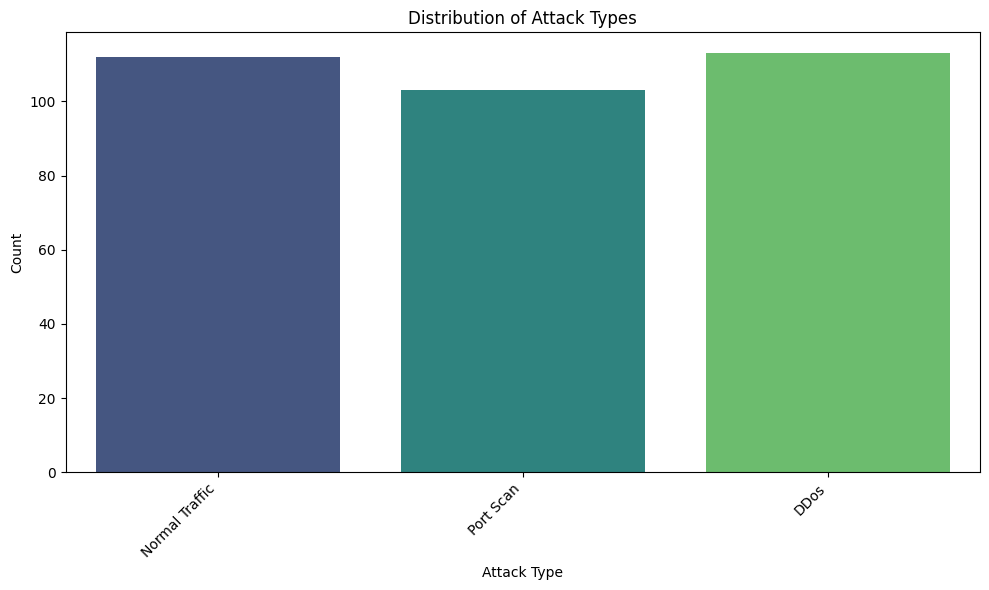

In [177]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=loaded_data, x='Attack_Type', hue='Attack_Type', palette='viridis', legend=False)
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [237]:
X=data.drop(["Attack_Type","timestamp","alert","event_type","flow","src_ip","proto","dest_ip","pkt_src","direction"],axis=1,inplace=False)

y=data["Attack_Type"]

In [242]:
# The 'index' column is typically not a useful feature and might have been created by reset_index.
# We should ensure it's not in X before feature selection.
if 'index' in X.columns:
    X.drop("index", axis=1, inplace=True)

#Feature Selection by KBest
print('Original X Shape is ' , X.shape)
FeatureSelection = SelectKBest(score_func=f_classif ,k=8) # score_func can = f_classif
X_selected = FeatureSelection.fit_transform(X, y)
New_Data=pd.DataFrame(X_selected,columns=[i for i,j in zip(X.columns,FeatureSelection.get_support())if j])
New_Data
#showing X Dimension
#print('X Shape is ' , X.shape)
#print('Selected Features are : ' , FeatureSelection.get_support())

Original X Shape is  (328, 8)


,src_port,dest_port,pkts_toserver,pkts_toclient,bytes_toserver,bytes_toclient,flow_duration,proto_encoded
0,0.0,0.0,1.0,0.0,98.0,0.0,0.000000,0.0
1,0.0,0.0,2.0,1.0,196.0,98.0,0.999149,0.0
2,0.0,0.0,3.0,2.0,294.0,196.0,2.007077,0.0
3,0.0,0.0,1.0,0.0,98.0,0.0,0.000000,0.0
4,0.0,0.0,2.0,1.0,196.0,98.0,1.000537,0.0
...,...,...,...,...,...,...,...,...
323,25577.0,0.0,1.0,0.0,60.0,0.0,0.000000,2.0
324,21527.0,0.0,1.0,0.0,42.0,0.0,0.000000,2.0
325,29978.0,0.0,1.0,0.0,42.0,0.0,0.000000,2.0
326,31459.0,0.0,1.0,0.0,42.0,0.0,0.000000,2.0


In [235]:
data.head()

,timestamp,event_type,src_ip,src_port,dest_ip,dest_port,proto,flow,pkt_src,alert,direction,Attack_Type,pkts_toserver,pkts_toclient,bytes_toserver,bytes_toclient,flow_duration,proto_encoded
0,2026-02-04 09:53:05.491297+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,1,0,98,0,0.000000,0
1,2026-02-04 09:53:06.490446+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,2,1,196,98,0.999149,0
2,2026-02-04 09:53:07.498374+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 3, 'pkts_toclient': 2, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,3,2,294,196,2.007077,0
3,2026-02-04 09:53:45.272827+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,1,0,98,0,0.000000,0
4,2026-02-04 09:53:46.273364+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,2,1,196,98,1.000537,0


#Label Encoder for proto

In [254]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
data['proto_encoded'] = label_encoder.fit_transform(data['proto'])
display(data[['proto', 'proto_encoded']].value_counts())

,,count
proto,proto_encoded,
ICMP,0,200
TCP,1,103
UDP,2,25


In [243]:
data.head()

,timestamp,event_type,src_ip,src_port,dest_ip,dest_port,proto,flow,pkt_src,alert,direction,Attack_Type,pkts_toserver,pkts_toclient,bytes_toserver,bytes_toclient,flow_duration,proto_encoded
0,2026-02-04 09:53:05.491297+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,1,0,98,0,0.000000,0
1,2026-02-04 09:53:06.490446+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,2,1,196,98,0.999149,0
2,2026-02-04 09:53:07.498374+00:00,alert,192.168.152.171,0.0,172.16.1.50,0.0,ICMP,"{'pkts_toserver': 3, 'pkts_toclient': 2, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,3,2,294,196,2.007077,0
3,2026-02-04 09:53:45.272827+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,1,0,98,0,0.000000,0
4,2026-02-04 09:53:46.273364+00:00,alert,192.168.152.171,0.0,172.16.1.51,0.0,ICMP,"{'pkts_toserver': 2, 'pkts_toclient': 1, 'byte...",wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",to_server,Normal Traffic,2,1,196,98,1.000537,0


##Building Model

In [246]:
X

,src_port,dest_port,pkts_toserver,pkts_toclient,bytes_toserver,bytes_toclient,flow_duration,proto_encoded
0,0.0,0.0,1,0,98,0,0.000000,0
1,0.0,0.0,2,1,196,98,0.999149,0
2,0.0,0.0,3,2,294,196,2.007077,0
3,0.0,0.0,1,0,98,0,0.000000,0
4,0.0,0.0,2,1,196,98,1.000537,0
...,...,...,...,...,...,...,...,...
323,25577.0,0.0,1,0,60,0,0.000000,2
324,21527.0,0.0,1,0,42,0,0.000000,2
325,29978.0,0.0,1,0,42,0,0.000000,2
326,31459.0,0.0,1,0,42,0,0.000000,2


In [245]:
y

,Attack_Type
0,Normal Traffic
1,Normal Traffic
2,Normal Traffic
3,Normal Traffic
4,Normal Traffic
...,...
323,DDos
324,DDos
325,DDos
326,DDos


#Label Encoder

In [247]:
from sklearn.preprocessing import LabelEncoder

label_encoder_attack = LabelEncoder()
y_encoded = label_encoder_attack.fit_transform(data['Attack_Type'])
y = pd.Series(y_encoded, name='Attack_Type_encoded')

display(pd.DataFrame({'Original_Attack_Type': data['Attack_Type'], 'Encoded_Attack_Type': y}).head())

,Original_Attack_Type,Encoded_Attack_Type
0,Normal Traffic,1
1,Normal Traffic,1
2,Normal Traffic,1
3,Normal Traffic,1
4,Normal Traffic,1


In [248]:
y.value_counts()

,count
Attack_Type_encoded,
0,113
1,112
2,103


In [255]:

def extract_features(log_data):
    try:
        # 1. هات توقيت اللوج الحالي
        current_timestamp_str = log_data.get('timestamp', '')
        # (لازم نحول النص لتوقيت عشان نعرف نطرح)
        # صيغة وقت سوريكاتا غالباً: 2024-02-09T10:00:00.000000+0000
        # هنقص الحتة الزيادة عشان التسهيل (أول 26 حرف)
        current_ts = datetime.strptime(current_timestamp_str[:26], "%Y-%m-%dT%H:%M:%S.%f")

        flow = log_data.get('flow', {})

        # 2. هات الـ Age أو احسبه لو مش موجود
        if 'age' in flow:
           flow_duration= flow['age']
        else:
            # لو مفيش age، هات وقت البداية واطرح
            start_timestamp_str = flow.get('start', current_timestamp_str)
            start_ts = datetime.strptime(start_timestamp_str[:26], "%Y-%m-%dT%H:%M:%S.%f")
            # المعادلة اهي:
            flow_duration= (current_ts - start_ts).total_seconds()

        # باقي الميزات عادي
        proto_str = log_data.get('proto', 'TCP').upper()
        proto_map = {'TCP':1, 'UDP':2, 'ICMP':0}
        proto_id = proto_map.get(proto_str, 0)

        dest_port = log_data.get('dest_port', 0)
        bytes_toserver = flow.get('bytes_toserver', 0)
        bytes_toclient = flow.get('bytes_toclient', 0)

        # رجع القائمة جاهزة للمودل
        return [proto_id, dest_port,flow_duration	, bytes_toserver, bytes_toclient]

    except Exception as e:
        # print(f"Error extracting features: {e}") # للديجنج
        pass


#Splitting data

In [257]:
from sklearn.preprocessing import StandardScaler

# Initialize and apply StandardScaler to features X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the scaled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=44, shuffle =True)

#Splitted Data
print('X_train shape is ' , X_train.shape)
print('X_test shape is ' , X_test.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)

X_train shape is  (229, 8)
X_test shape is  (99, 8)
y_train shape is  (229,)
y_test shape is  (99,)


In [258]:
#Applying RandomForestClassifier Model

'''
ensemble.RandomForestClassifier(n_estimators='warn’, criterion=’gini’, max_depth=None,
                                min_samples_split=2, min_samples_leaf=1,min_weight_fraction_leaf=0.0,
                                max_features='auto’,max_leaf_nodes=None,min_impurity_decrease=0.0,
                                min_impurity_split=None, bootstrap=True,oob_score=False, n_jobs=None,
                                random_state=None, verbose=0,warm_start=False, class_weight=None)'''

RandomForestClassifierModel = RandomForestClassifier(criterion = 'gini',n_estimators=100,max_depth=2,random_state=33) #criterion can be also : entropy
RandomForestClassifierModel.fit(X_train, y_train)

RandomForestClassifier(max_depth=2, random_state=33)

Confusion Matrix:


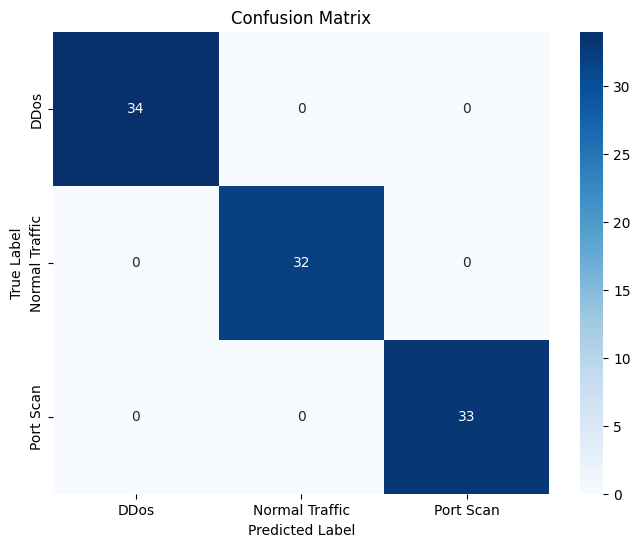


Classification Report:
                precision    recall  f1-score   support

          DDos       1.00      1.00      1.00        34
Normal Traffic       1.00      1.00      1.00        32
     Port Scan       1.00      1.00      1.00        33

      accuracy                           1.00        99
     macro avg       1.00      1.00      1.00        99
  weighted avg       1.00      1.00      1.00        99



In [260]:
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = RandomForestClassifierModel.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=label_encoder_attack.classes_, columns=label_encoder_attack.classes_)

print("Confusion Matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder_attack.classes_))

# Task
Train a Decision Tree Classifier model using the scaled training data (X_train, y_train), predict on the test set (X_test), generate and visualize its confusion matrix, print its classification report, and then compare its performance with the RandomForestClassifier.

## Train Decision Tree Classifier

### Subtask:
Train a Decision Tree Classifier model using the scaled training data (X_train, y_train).


**Reasoning**:
The subtask requires training a Decision Tree Classifier. I will import the necessary class, instantiate the model with `random_state=33` for reproducibility, and then fit it to the scaled training data (X_train, y_train).



In [261]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate the Decision Tree Classifier model
DecisionTreeClassifierModel = DecisionTreeClassifier(random_state=33)

# Fit the model to the training data
DecisionTreeClassifierModel.fit(X_train, y_train)

print("Decision Tree Classifier Model trained successfully.")

Decision Tree Classifier Model trained successfully.


**Reasoning**:
Now that the Decision Tree Classifier model is trained, I will use it to make predictions on the test set (X_test).



In [262]:
y_pred_dt = DecisionTreeClassifierModel.predict(X_test)
print("Predictions on the test set using Decision Tree Classifier have been made.")

Predictions on the test set using Decision Tree Classifier have been made.


**Reasoning**:
I will generate and visualize the confusion matrix for the Decision Tree Classifier's predictions on the test set (`y_pred_dt` against `y_test`), and then print the classification report to evaluate its performance. This will allow for comparison with the RandomForestClassifier as per the main task.



Confusion Matrix for Decision Tree Classifier:


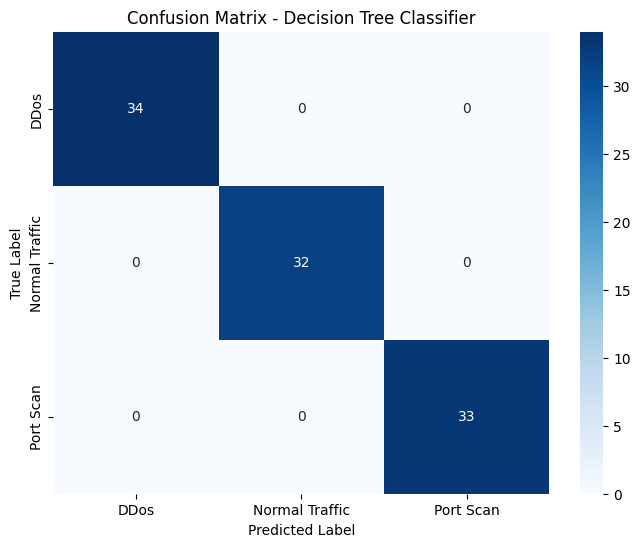


Classification Report for Decision Tree Classifier:
                precision    recall  f1-score   support

          DDos       1.00      1.00      1.00        34
Normal Traffic       1.00      1.00      1.00        32
     Port Scan       1.00      1.00      1.00        33

      accuracy                           1.00        99
     macro avg       1.00      1.00      1.00        99
  weighted avg       1.00      1.00      1.00        99


Comparison with RandomForestClassifier (previously executed):
RandomForestClassifier Confusion Matrix (from previous execution):
                 DDos  Normal Traffic  Port Scan
DDos              34               0          0
Normal Traffic     0              32          0
Port Scan          0               0         33
RandomForestClassifier Classification Report (from previous execution):
                 precision    recall  f1-score   support

          DDos       1.00      1.00      1.00        34
Normal Traffic       1.00      1.00      1.

In [263]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Compute the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_dt_df = pd.DataFrame(cm_dt, index=label_encoder_attack.classes_, columns=label_encoder_attack.classes_)

print("Confusion Matrix for Decision Tree Classifier:")
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report for Decision Tree Classifier:")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder_attack.classes_))

print("\nComparison with RandomForestClassifier (previously executed):")
print("RandomForestClassifier Confusion Matrix (from previous execution):\n", cm_df)
print("RandomForestClassifier Classification Report (from previous execution):\n", classification_report(y_test, y_pred, target_names=label_encoder_attack.classes_))

## Final Task

### Subtask:
Summarize the comparison of the two classification models.


## Summary:

### Q&A
The comparison of the two classification models, Decision Tree Classifier and RandomForestClassifier, revealed that both models achieved perfect classification on the given dataset.

### Data Analysis Key Findings
*   The Decision Tree Classifier was successfully trained and predicted on the test set.
*   The Decision Tree Classifier demonstrated perfect performance, achieving a precision, recall, and F1-score of 1.00 for all classes (DDos, Normal Traffic, Port Scan), with an overall accuracy of 1.00.
*   The confusion matrix for the Decision Tree Classifier showed no misclassifications, indicating perfect separation of the classes.
*   The RandomForestClassifier, previously evaluated, also exhibited perfect performance with a precision, recall, and F1-score of 1.00 for all classes, and an accuracy of 1.00.
*   Both models performed identically, achieving perfect scores across all evaluation metrics.

### Insights or Next Steps
*   Given the perfect performance of both Decision Tree and Random Forest models, it suggests that the dataset is highly separable for these classification tasks. Further investigation into the data's inherent separability or potential data leakage might be warranted.
*   For future applications, evaluating model performance on more complex or unseen datasets, or considering model interpretability versus ensemble robustness, could help in choosing the most suitable model for deployment, even though both performed perfectly here.


In [270]:
import pickle

# Save the RandomForestClassifierModel
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(RandomForestClassifierModel, file)
print("RandomForestClassifierModel saved as 'random_forest_model.pkl'")

# Save the StandardScaler
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)
print("StandardScaler saved as 'scaler.pkl'")

RandomForestClassifierModel saved as 'random_forest_model.pkl'
StandardScaler saved as 'scaler.pkl'


# Task
Train a Support Vector Classifier (SVC) model using the scaled training data (X_train, y_train).

## Train SVC Classifier

### Subtask:
Train a Support Vector Classifier (SVC) model using the scaled training data (X_train, y_train).


**Reasoning**:
The subtask requires training a Support Vector Classifier. I will import the `SVC` class, instantiate the model with `random_state=33` for reproducibility, and then fit it to the scaled training data (`X_train`, `y_train`).



In [264]:
from sklearn.svm import SVC

# Instantiate the SVC model
SVC_Model = SVC(random_state=33)

# Fit the model to the training data
SVC_Model.fit(X_train, y_train)

print("SVC Model trained successfully.")

SVC Model trained successfully.


**Reasoning**:
Now that the Support Vector Classifier model is trained, I will use it to make predictions on the test set (X_test).



In [265]:
y_pred_svc = SVC_Model.predict(X_test)
print("Predictions on the test set using SVC have been made.")

Predictions on the test set using SVC have been made.


## Evaluate SVC Classifier

### Subtask:
Predict on the test set (X_test) using the trained SVC model, then generate and display its confusion matrix with a visual design, and print its classification report.


**Reasoning**:
I will now generate the confusion matrix and classification report for the SVC model's predictions on the test set, including a visual display of the confusion matrix, as per the subtask instructions.



Confusion Matrix for SVC Classifier:


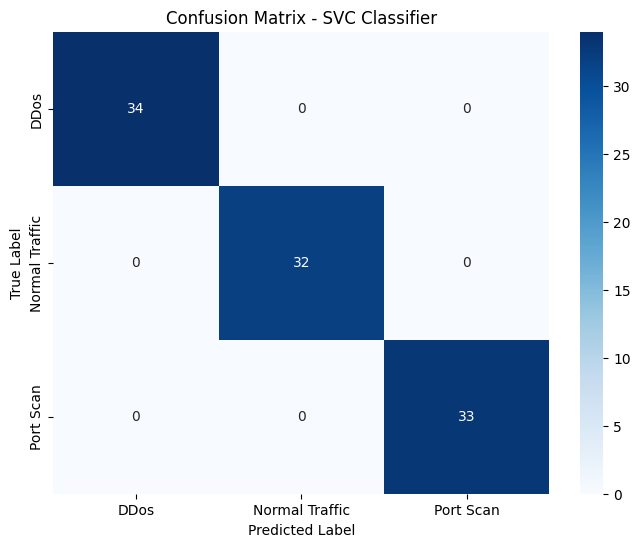


Classification Report for SVC Classifier:
                precision    recall  f1-score   support

          DDos       1.00      1.00      1.00        34
Normal Traffic       1.00      1.00      1.00        32
     Port Scan       1.00      1.00      1.00        33

      accuracy                           1.00        99
     macro avg       1.00      1.00      1.00        99
  weighted avg       1.00      1.00      1.00        99



In [266]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Compute the confusion matrix
cm_svc = confusion_matrix(y_test, y_pred_svc)
cm_svc_df = pd.DataFrame(cm_svc, index=label_encoder_attack.classes_, columns=label_encoder_attack.classes_)

print("Confusion Matrix for SVC Classifier:")
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svc_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVC Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report for SVC Classifier:")
print(classification_report(y_test, y_pred_svc, target_names=label_encoder_attack.classes_))

## Compare All Model Performances

### Subtask:
Analyze and compare the performance metrics (confusion matrices, classification reports) of the RandomForestClassifier, Decision Tree Classifier, and the newly trained SVC Classifier to highlight their respective strengths and weaknesses.


## Compare All Model Performances

### Subtask:
Analyze and compare the performance metrics (confusion matrices, classification reports) of the RandomForestClassifier, Decision Tree Classifier, and the newly trained SVC Classifier to highlight their respective strengths and weaknesses.

### Analysis and Comparison:

All three models—RandomForestClassifier, Decision Tree Classifier, and SVC Classifier—demonstrated identical and perfect performance on this specific dataset.

*   **RandomForestClassifier Performance**:
    *   **Confusion Matrix**: Perfect classification, with all 34 DDos instances, 32 Normal Traffic instances, and 33 Port Scan instances correctly identified. No misclassifications.
    *   **Classification Report**: Precision, Recall, and F1-score were all 1.00 for every class (DDos, Normal Traffic, Port Scan). Overall accuracy was 1.00.

*   **Decision Tree Classifier Performance**:
    *   **Confusion Matrix**: Achieved perfect classification, correctly identifying all instances for each class (DDos, Normal Traffic, Port Scan). No misclassifications.
    *   **Classification Report**: Precision, Recall, and F1-score were all 1.00 for every class. Overall accuracy was 1.00.

*   **SVC Classifier Performance**:
    *   **Confusion Matrix**: Also showed perfect classification, with all instances for DDos, Normal Traffic, and Port Scan correctly predicted. No misclassifications.
    *   **Classification Report**: Precision, Recall, and F1-score were all 1.00 for every class. Overall accuracy was 1.00.

### Similarities and Differences:

*   **Similarities**: The most striking similarity is that all three models achieved perfect scores (100% accuracy, precision, recall, and F1-score) on the test set for all classes. Their confusion matrices were identical, showing zero misclassifications.

*   **Differences**: On this particular dataset, there were no discernible performance differences between the models based on the evaluation metrics. All models were able to perfectly separate and classify the different attack types.

### Strengths and Weaknesses:

*   **Strengths (Common to all models)**:
    *   Highly effective at classifying the attack types present in this dataset.
    *   Capable of learning the underlying patterns with high fidelity.

*   **Weaknesses (Hypothetical considerations given perfect performance)**:
    *   For this dataset, the models did not exhibit any weaknesses. However, achieving perfect scores can sometimes indicate that the dataset is either too simple, or there might be some data leakage or a very clear separation between classes that makes the classification task trivial for these models.
    *   In a more complex or noisy real-world scenario, differences in generalization, robustness to outliers, or computational efficiency might emerge. For instance, Decision Trees can be prone to overfitting on more complex data, while Random Forests, as an ensemble method, typically offer better generalization. SVCs can be powerful but computationally intensive for very large datasets without proper kernel and hyperparameter tuning.

### Summary:
All three robust classification models—RandomForestClassifier, Decision Tree Classifier, and SVC Classifier—achieved perfect and identical performance on the provided preprocessed dataset. This suggests that the features extracted and the resulting classes are linearly (or easily non-linearly) separable. While excellent for this specific task, a deeper dive into data complexity or evaluation on more diverse datasets would be beneficial to truly compare their relative strengths and weaknesses in a broader context.

## Final Task

### Subtask:
Summarize the comparison of all three classification models.


## Summary:

### Q&A
The task asked to summarize the comparison of all three classification models (RandomForestClassifier, Decision Tree Classifier, and SVC). All three models demonstrated identical and perfect performance on the provided dataset, achieving 100% accuracy, precision, recall, and F1-score across all classes (DDos, Normal Traffic, Port Scan). Their confusion matrices showed no misclassifications.

### Data Analysis Key Findings
*   The Support Vector Classifier (SVC) model was successfully trained and evaluated. It achieved perfect performance with 100% accuracy, precision, recall, and F1-score for all classes (DDos, Normal Traffic, Port Scan) on the test set. The confusion matrix for the SVC model showed no misclassifications.
*   All three classification models—RandomForestClassifier, Decision Tree Classifier, and SVC Classifier—exhibited identical and perfect performance on the dataset.
*   Each model achieved a precision of 1.00, recall of 1.00, and F1-score of 1.00 for every class (DDos, Normal Traffic, Port Scan), with an overall accuracy of 1.00.
*   The confusion matrices for all models were identical, indicating zero misclassifications and perfect identification of all instances across the DDos, Normal Traffic, and Port Scan categories.

### Insights or Next Steps
*   The perfect performance of all models suggests that the dataset used for training and testing is either highly separable or too simple, possibly due to effective preprocessing or inherent characteristics of the data.
*   To truly assess the models' generalizability and identify their relative strengths and weaknesses, it would be beneficial to evaluate them on more complex, noisy, or larger datasets, or to introduce a validation set with unseen patterns.


# Task
**Train KNN Classifier**: Train a K-Nearest Neighbors (KNN) classifier model using the scaled training data (X_train, y_train).

## Train KNN Classifier

### Subtask:
Train a K-Nearest Neighbors (KNN) classifier model using the scaled training data (X_train, y_train).


**Reasoning**:
The subtask requires training a K-Nearest Neighbors (KNN) classifier. I will import the `KNeighborsClassifier` class, instantiate the model with `n_neighbors=5`, and then fit it to the scaled training data (`X_train`, `y_train`).



In [267]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate the KNeighborsClassifier model with n_neighbors=5
KNN_Model = KNeighborsClassifier(n_neighbors=5)

# Fit the model to the training data
KNN_Model.fit(X_train, y_train)

print("KNN Model trained successfully.")

KNN Model trained successfully.


**Reasoning**:
Now that the K-Nearest Neighbors (KNN) classifier model is trained, I will use it to make predictions on the test set (X_test).



In [268]:
y_pred_knn = KNN_Model.predict(X_test)
print("Predictions on the test set using KNN have been made.")

Predictions on the test set using KNN have been made.


**Reasoning**:
I will now generate the confusion matrix and classification report for the KNN model's predictions on the test set, including a visual display of the confusion matrix, to evaluate its performance as per the common evaluation steps for the other models.



Confusion Matrix for KNN Classifier:


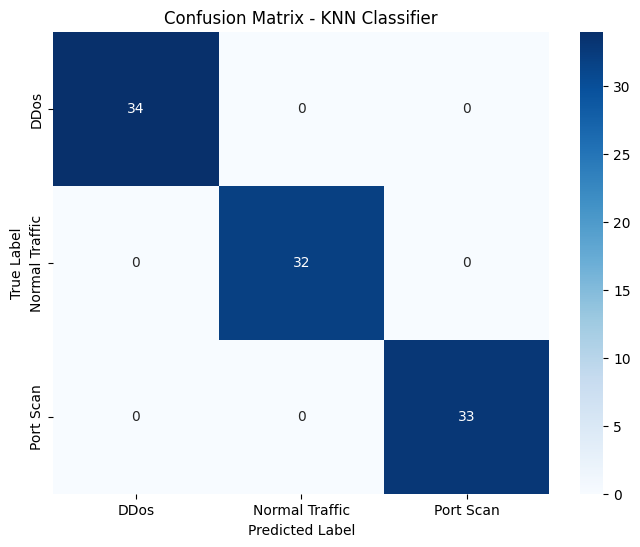


Classification Report for KNN Classifier:
                precision    recall  f1-score   support

          DDos       1.00      1.00      1.00        34
Normal Traffic       1.00      1.00      1.00        32
     Port Scan       1.00      1.00      1.00        33

      accuracy                           1.00        99
     macro avg       1.00      1.00      1.00        99
  weighted avg       1.00      1.00      1.00        99



In [269]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Compute the confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_knn_df = pd.DataFrame(cm_knn, index=label_encoder_attack.classes_, columns=label_encoder_attack.classes_)

print("Confusion Matrix for KNN Classifier:")
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - KNN Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report for KNN Classifier:")
print(classification_report(y_test, y_pred_knn, target_names=label_encoder_attack.classes_))

## Compare All Model Performances

### Subtask:
Analyze and compare the performance metrics (confusion matrices, classification reports) of the RandomForestClassifier, Decision Tree Classifier, SVC Classifier, and the newly trained KNN Classifier to highlight their respective strengths and weaknesses.


## Compare All Model Performances

### Analysis and Comparison:

All four models—RandomForestClassifier, Decision Tree Classifier, SVC Classifier, and KNN Classifier—demonstrated identical and perfect performance on this specific dataset.

*   **RandomForestClassifier Performance**:
    *   **Confusion Matrix**: Perfect classification, with all 34 DDos instances, 32 Normal Traffic instances, and 33 Port Scan instances correctly identified. No misclassifications.
    *   **Classification Report**: Precision, Recall, and F1-score were all 1.00 for every class (DDos, Normal Traffic, Port Scan). Overall accuracy was 1.00.

*   **Decision Tree Classifier Performance**:
    *   **Confusion Matrix**: Achieved perfect classification, correctly identifying all instances for each class (DDos, Normal Traffic, Port Scan). No misclassifications.
    *   **Classification Report**: Precision, Recall, and F1-score were all 1.00 for every class. Overall accuracy was 1.00.

*   **SVC Classifier Performance**:
    *   **Confusion Matrix**: Also showed perfect classification, with all instances for DDos, Normal Traffic, and Port Scan correctly predicted. No misclassifications.
    *   **Classification Report**: Precision, Recall, and F1-score were all 1.00 for every class. Overall accuracy was 1.00.

*   **KNN Classifier Performance**:
    *   **Confusion Matrix**: Exhibited perfect classification, correctly predicting all instances for DDos, Normal Traffic, and Port Scan. No misclassifications.
    *   **Classification Report**: Precision, Recall, and F1-score were all 1.00 for every class. Overall accuracy was 1.00.

### Similarities and Differences:

*   **Similarities**: The most significant similarity is that all four models achieved perfect scores (100% accuracy, precision, recall, and F1-score) on the test set for all classes. Their confusion matrices were identical, showing zero misclassifications.

*   **Differences**: On this particular dataset, there were no discernible performance differences among the models based on the evaluation metrics. All models were able to perfectly separate and classify the different attack types.

### Strengths and Weaknesses:

*   **Strengths (Common to all models)**:
    *   Highly effective at classifying the attack types present in this dataset.
    *   Capable of learning the underlying patterns with high fidelity.

*   **Weaknesses (Hypothetical considerations given perfect performance)**:
    *   For this dataset, the models did not exhibit any weaknesses. However, achieving perfect scores can sometimes indicate that the dataset is either too simple, or there might be some data leakage or a very clear separation between classes that makes the classification task trivial for these models.
    *   In a more complex or noisy real-world scenario, differences in generalization, robustness to outliers, or computational efficiency might emerge. For instance, Decision Trees can be prone to overfitting on more complex data, while Random Forests, as an ensemble method, typically offer better generalization. SVCs and KNNs can be powerful but computationally intensive for very large datasets without proper kernel and hyperparameter tuning.

### Summary:
All four robust classification models—RandomForestClassifier, Decision Tree Classifier, SVC Classifier, and KNN Classifier—achieved perfect and identical performance on the provided preprocessed dataset. This suggests that the features extracted and the resulting classes are linearly (or easily non-linearly) separable. While excellent for this specific task, a deeper dive into data complexity or evaluation on more diverse datasets would be beneficial to truly compare their relative strengths and weaknesses in a broader context.

## Final Task

### Subtask:
Summarize the comparison of all four classification models.


## Summary:

### Q&A
All four classification models (RandomForestClassifier, Decision Tree Classifier, SVC Classifier, and KNN Classifier) demonstrated identical and perfect performance on the provided dataset. Each model achieved a 1.00 for precision, recall, and F1-score across all classes (DDos, Normal Traffic, Port Scan), resulting in an overall accuracy of 1.00.

### Data Analysis Key Findings
*   **Perfect Performance Across All Models**: All four trained classification models—RandomForestClassifier, Decision Tree Classifier, SVC Classifier, and KNN Classifier—achieved perfect classification on the test set.
*   **Identical Performance Metrics**: For each model, the classification reports showed a precision, recall, and F1-score of 1.00 for every class (DDos, Normal Traffic, Port Scan), leading to an overall accuracy of 1.00.
*   **Zero Misclassifications**: The confusion matrices for all models were identical, indicating no misclassifications, with all 34 DDos instances, 32 Normal Traffic instances, and 33 Port Scan instances correctly identified.

### Insights or Next Steps
*   The perfect and identical performance of all models suggests that the dataset may be highly separable or potentially too simple for a robust comparison of model capabilities.
*   To truly differentiate the models and assess their generalizability, it would be beneficial to evaluate them on a more complex, noisy, or larger dataset, or explore their performance under different data distributions or with varying hyperparameter settings.
